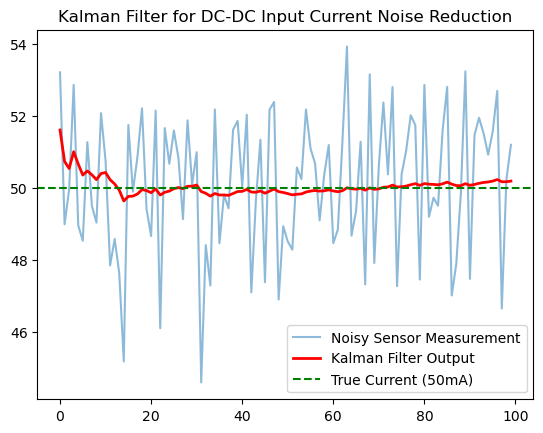

In [152]:
import numpy as np
import matplotlib.pyplot as plt

class SimpleKalmanFilter:
    def __init__(self, process_noise, measurement_noise, initial_estimate, initial_error):
        """
        [칼만 필터 파라미터 초기값 설정 가이드]
        
        1. process_noise (Q): 시스템 자체의 변동성(잡음 분산)
           - 물리적 상태가 시간 단계마다 실제로 변화할 수 있는 불확실성을 의미합니다.
           - 정적인 시스템 (전류가 거의 변하지 않음): 1e-5 ~ 1e-3 (부드러운 필터링)
           - 동적인 시스템 (전류가 자주/급격히 변함): 1e-2 ~ 0.5 (빠른 반응성)
           - Q/R 비율을 조정하여 필터의 '반응성'과 '부드러움' 사이를 튜닝합니다.
        
        2. measurement_noise (R): 센서의 측정 잡음 분산
           - 센서 사양서의 오차 표준편차(sigma)의 제곱 또는 정지 상태의 센서 데이터 분산값을 사용합니다.
           - 예: 표준편차가 2.0mA 수준이면 R = 2.0^2 = 4.0으로 설정합니다.
        
        3. initial_estimate (x_est): 초기 추정 상태값
           - 필터가 최초에 작동을 시작할 때 설정하는 시작 상태(전류값)입니다.
           - 정밀할 필요는 없으며, 대개 첫 번째 센서 측정값을 그대로 사용하거나 시스템의 정격 값을 지정합니다.
        
        4. initial_error (P): 초기 오차 공분산
           - 초기 추정값(initial_estimate)이 얼마나 불확실한지 나타내는 신뢰도입니다.
           - 초기값을 정확히 안다면 작게(0.1 ~ 1.0), 모른다면 크게(100.0 ~ 1000.0) 설정합니다.
           - 필터가 몇 번 작동하면 최적값으로 자동 수렴하므로 보통 R과 비슷한 값으로 시작합니다.
        """
        self.Q = process_noise 
        self.R = measurement_noise 
        self.x_est = initial_estimate # 초기 추정 상태 (전류값)
        self.P = initial_error        # 초기 오차 공분산

    def update(self, measurement):
        # 1. 예측 (Prediction)
        # 1D 단순 직류 모델이므로 이전 상태를 현재 상태로 예측
        x_pred = self.x_est
        P_pred = self.P + self.Q

        # 2. 업데이트 (Update)
        # 칼만 이득(Kalman Gain) 계산
        K = P_pred / (P_pred + self.R)
        
        # 새로운 측정값을 바탕으로 추정치 업데이트
        self.x_est = x_pred + K * (measurement - x_pred)
        
        # 오차 공분산 업데이트
        self.P = (1 - K) * P_pred

        return self.x_est

# --- 테스트 시뮬레이션 ---
# 실제 소모 전류가 50mA인 상황에서 2mA 수준의 랜덤 노이즈가 발생하는 상황 가정
true_current = 50.0 
measurements = [true_current + np.random.normal(0, 2.0) for _ in range(100)]

# 칼만 필터 초기화 (Q, R 값은 실험을 통해 튜닝 필요)
kf = SimpleKalmanFilter(process_noise=1e-3, measurement_noise=4.0, initial_estimate=50.0, initial_error=4.0)

filtered_current = [kf.update(z) for z in measurements]

# 결과 출력
plt.plot(measurements, label='Noisy Sensor Measurement', alpha=0.5)
plt.plot(filtered_current, label='Kalman Filter Output', color='red', linewidth=2)
plt.axhline(true_current, color='green', linestyle='dashed', label='True Current (50mA)')
plt.legend()
plt.title("Kalman Filter for DC-DC Input Current Noise Reduction")
plt.show()

In [153]:
measurements

[53.20575290429064,
 48.98333665012184,
 49.9441219448993,
 52.85796891956158,
 48.94913787236132,
 48.52640572276993,
 51.26643448526772,
 49.49054976485103,
 49.03054778115241,
 52.07235499949056,
 50.748802046084904,
 47.83969867516922,
 48.575162368410574,
 47.623318690690326,
 45.17117304391345,
 51.7437319174233,
 49.893498107747284,
 50.8587395509633,
 52.20706021576723,
 49.40261859644112,
 48.65550003260126,
 52.142406887258986,
 46.0920627506668,
 51.65624836432852,
 50.664181679866616,
 51.59029182414521,
 50.82896077000283,
 49.12596822467795,
 51.87166316610321,
 50.0920866795127,
 50.98679409360243,
 44.58564727453904,
 48.40385432834816,
 47.279645909952166,
 52.17355892134965,
 48.45379431373241,
 49.79912079801066,
 49.429028667305545,
 51.61204899810164,
 51.85623328897717,
 50.028711683286204,
 52.028721096282275,
 47.090704072751656,
 49.62682830966907,
 51.33413837453914,
 47.37304388658337,
 52.16922649634436,
 52.38316555958246,
 46.891631413849865,
 48.929795702

In [154]:
filtered_current

[51.603076786660026,
 50.72946630656216,
 50.53295848646366,
 50.998657692826065,
 50.656288846472115,
 50.35103194218561,
 50.4659572335479,
 50.35696545096822,
 50.22338042628693,
 50.39293642611297,
 50.42290366874955,
 50.221719533913856,
 50.10239444971738,
 49.934338380161705,
 49.630899451926965,
 49.75790371203831,
 49.76562240451663,
 49.82474112354878,
 49.94750864531852,
 49.92068188867848,
 49.861028323274155,
 49.96427231663784,
 49.795736315892846,
 49.87376369804783,
 49.90576047247464,
 49.97168756429862,
 50.00417326806577,
 49.971905640901994,
 50.039675805405984,
 50.041493275309364,
 50.07339584984961,
 49.89295484869946,
 49.8452019950845,
 49.76488345696213,
 49.83856757192874,
 49.797137348778485,
 49.79719543396306,
 49.78663359516956,
 49.837971233931604,
 49.893657003573374,
 49.897315206457776,
 49.954030662078814,
 49.87913504808662,
 49.87264383356989,
 49.90964847974925,
 49.846405297951115,
 49.90346226942047,
 49.9635029356183,
 49.89015063108116,
 49.86